In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [9]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [67]:
xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [11]:
file_path = "../data/raw/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)

xls.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [12]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name=0
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name=1
)

In [13]:
print(df_2009_2010.shape)
print(df_2010_2011.shape)

(525461, 8)
(541910, 8)


In [14]:
df_2009_2010.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
df_2010_2011.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

In [17]:
df.shape

(1067371, 8)

In [18]:
expected_rows = 1_067_371

actual_rows = len(df)

print("Expected:", expected_rows)
print("Actual:", actual_rows)
print("Match:", actual_rows == expected_rows)

Expected: 1067371
Actual: 1067371
Match: True


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [20]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [21]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (
        df.isna().mean().values * 100
    ).round(2),
    "Unique Values": df.nunique().values
})

data_dictionary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Invoice,object,0,0.00,53628
1,StockCode,object,0,0.00,5305
2,Description,object,4382,0.41,5698
3,Quantity,int64,0,0.00,1057
4,InvoiceDate,datetime64[us],0,0.00,47635
5,Price,float64,0,0.00,2807
6,Customer ID,float64,243007,22.77,5942
7,Country,str,0,0.00,43


In [22]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [23]:
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct.round(2)
})

missing_report

,Missing Count,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [24]:
missing_customer = df["Customer ID"].isna().sum()

missing_customer_pct = (
    missing_customer / len(df)
) * 100

print("Missing Customer IDs:", missing_customer)
print("Percentage:", round(missing_customer_pct, 2), "%")

Missing Customer IDs: 243007
Percentage: 22.77 %


In [26]:
df["Invoice"] = df["Invoice"].astype(str)

df["IsCancellation"] = (
    df["Invoice"]
    .str.upper()
    .str.startswith("C")
)

df["IsCancellation"].value_counts()

IsCancellation
False    1047877
True       19494
Name: count, dtype: int64

In [27]:
cancellation_pct = (
    df["IsCancellation"].mean() * 100
)

print(
    f"Cancellation records: "
    f"{cancellation_pct:.2f}%"
)

Cancellation records: 1.83%


In [28]:
df[df["IsCancellation"]].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True


In [29]:
df.loc[
    df["IsCancellation"],
    "Quantity"
].describe()

count    19494.000000
mean       -25.186827
std        805.104908
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64

In [30]:
df["Quantity"].describe()

count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

In [31]:
print(
    "Negative quantities:",
    (df["Quantity"] < 0).sum()
)

print(
    "Zero quantities:",
    (df["Quantity"] == 0).sum()
)

print(
    "Positive quantities:",
    (df["Quantity"] > 0).sum()
)

Negative quantities: 22950
Zero quantities: 0
Positive quantities: 1044421


In [32]:
df[df["Quantity"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,True
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,True
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,True
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,True


In [33]:
df["Price"].describe()

count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64

In [34]:
print(
    "Zero prices:",
    (df["Price"] == 0).sum()
)

print(
    "Negative prices:",
    (df["Price"] < 0).sum()
)

Zero prices: 6202
Negative prices: 5


In [35]:
df[df["Price"] <= 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom,False


In [36]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 34335


In [37]:
print(
    "Duplicate percentage:",
    round(
        duplicate_count / len(df) * 100,
        2
    ),
    "%"
)

Duplicate percentage: 3.22 %


In [38]:
df[df.duplicated(keep=False)].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,False
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,False
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,False
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,False
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,False
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False


In [39]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [40]:
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00


In [41]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

In [42]:
df["Revenue"].describe()

count    1.067371e+06
mean     1.806987e+01
std      2.924202e+02
min     -1.684696e+05
25%      3.750000e+00
50%      9.900000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64

In [43]:
print("Total recorded revenue:")
print(df["Revenue"].sum())

Total recorded revenue:
19287250.568


In [44]:
identified_customers = (
    df["Customer ID"]
    .dropna()
    .nunique()
)

print(
    "Identifiable customers:",
    identified_customers
)

Identifiable customers: 5942


In [46]:
unique_invoices = df["Invoice"].nunique()

print(
    "Unique invoices:",
    unique_invoices
)

Unique invoices: 53628


In [47]:
unique_products = df["StockCode"].nunique()

print(
    "Unique products:",
    unique_products
)

Unique products: 5305


In [48]:
unique_countries = df["Country"].nunique()

print(
    "Countries:",
    unique_countries
)

Countries: 43


In [50]:
customer_orders = (
    df.dropna(subset=["Customer ID"])
      .groupby("Customer ID")["Invoice"]
      .nunique()
)

In [51]:
customer_orders.describe()

count    5942.000000
mean        7.552339
std        15.972262
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       510.000000
Name: Invoice, dtype: float64

In [52]:
customer_orders.sort_values(
    ascending=False
).head(20)

Customer ID
14911.0    510
12748.0    365
17841.0    289
15311.0    270
14606.0    259
13089.0    247
14156.0    202
14527.0    190
13694.0    164
14646.0    164
17850.0    159
18102.0    153
16422.0    146
15061.0    138
17949.0    138
13408.0    135
12471.0    129
13798.0    125
16029.0    125
12971.0    120
Name: Invoice, dtype: int64

In [53]:
customer_dates = (
    df.dropna(subset=["Customer ID"])
      .sort_values(["Customer ID", "InvoiceDate"])
      .groupby("Customer ID")["InvoiceDate"]
)

In [61]:
# ============================================================
# CUSTOMER PURCHASE INTERVAL ANALYSIS
# ============================================================

# Keep identifiable customers only
customer_df = df.dropna(subset=["Customer ID"]).copy()

# Remove cancellation invoices from purchase-behaviour analysis
customer_df = customer_df[
    ~customer_df["IsCancellation"]
].copy()

# Get one purchase date per customer per invoice
customer_invoices = (
    customer_df[
        ["Customer ID", "Invoice", "InvoiceDate"]
    ]
    .drop_duplicates()
    .sort_values(["Customer ID", "InvoiceDate"])
)

customer_invoices.head()

,Customer ID,Invoice,InvoiceDate
27994,12346.0,491725,2009-12-14 08:34:00
28251,12346.0,491742,2009-12-14 11:00:00
28254,12346.0,491744,2009-12-14 11:02:00
39398,12346.0,492718,2009-12-18 10:47:00
39411,12346.0,492722,2009-12-18 10:55:00


In [58]:
# Calculate days between actual customer invoices
customer_invoices["PurchaseIntervalDays"] = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    / (24 * 60 * 60)
)

purchase_intervals = customer_invoices[
    "PurchaseIntervalDays"
].dropna()

purchase_intervals.describe()

count    31158.000000
mean        51.575513
std         75.744891
min          0.000000
25%          6.969444
50%         24.194444
75%         61.190104
max        714.152083
Name: PurchaseIntervalDays, dtype: float64

In [59]:
purchase_interval_quantiles = purchase_intervals.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

purchase_interval_quantiles

0.50     24.194444
0.75     61.190104
0.90    134.123819
0.95    206.040069
0.99    368.279347
Name: PurchaseIntervalDays, dtype: float64

In [60]:
print("Number of customer purchase intervals:", len(purchase_intervals))
print("Mean:", round(purchase_intervals.mean(), 2))
print("Median:", round(purchase_intervals.median(), 2))
print("75th percentile:", round(purchase_intervals.quantile(0.75), 2))
print("90th percentile:", round(purchase_intervals.quantile(0.90), 2))
print("95th percentile:", round(purchase_intervals.quantile(0.95), 2))
print("99th percentile:", round(purchase_intervals.quantile(0.99), 2))
print("Maximum:", round(purchase_intervals.max(), 2))

Number of customer purchase intervals: 31158
Mean: 51.58
Median: 24.19
75th percentile: 61.19
90th percentile: 134.12
95th percentile: 206.04
99th percentile: 368.28
Maximum: 714.15


In [62]:
# ============================================================
# SAME-DAY PURCHASE INTERVAL DIAGNOSTICS
# ============================================================

zero_intervals = (purchase_intervals == 0).sum()
zero_interval_pct = (zero_intervals / len(purchase_intervals)) * 100

print("Zero-day purchase intervals:", zero_intervals)
print("Percentage of intervals that are zero-day:",
      round(zero_interval_pct, 2), "%")

Zero-day purchase intervals: 182
Percentage of intervals that are zero-day: 0.58 %


In [63]:
# Distribution excluding same-day intervals
positive_intervals = purchase_intervals[
    purchase_intervals > 0
]

print("Intervals greater than 0 days:", len(positive_intervals))
print("Median excluding same-day intervals:",
      round(positive_intervals.median(), 2))

print("90th percentile excluding same-day intervals:",
      round(positive_intervals.quantile(0.90), 2))

print("95th percentile excluding same-day intervals:",
      round(positive_intervals.quantile(0.95), 2))

Intervals greater than 0 days: 30976
Median excluding same-day intervals: 24.9
90th percentile excluding same-day intervals: 135.0
95th percentile excluding same-day intervals: 206.99


In [64]:
# ============================================================
# CANDIDATE INACTIVITY THRESHOLDS
# ============================================================

thresholds = [60, 90, 120, 134, 180]

# Last observed purchase for each customer
customer_last_purchase = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .max()
)

# Dataset observation end date
observation_end = customer_invoices["InvoiceDate"].max()

# Days since last purchase
customer_recency = (
    observation_end - customer_last_purchase
).dt.total_seconds() / (24 * 60 * 60)

threshold_results = []

for threshold in thresholds:
    inactive_count = (customer_recency > threshold).sum()
    total_customers = len(customer_recency)
    inactive_pct = (inactive_count / total_customers) * 100

    threshold_results.append({
        "Threshold_Days": threshold,
        "Inactive_Customers": inactive_count,
        "Total_Customers": total_customers,
        "Inactive_Percentage": round(inactive_pct, 2)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold_Days,Inactive_Customers,Total_Customers,Inactive_Percentage
0,60,3483,5881,59.22
1,90,2991,5881,50.86
2,120,2759,5881,46.91
3,134,2666,5881,45.33
4,180,2402,5881,40.84


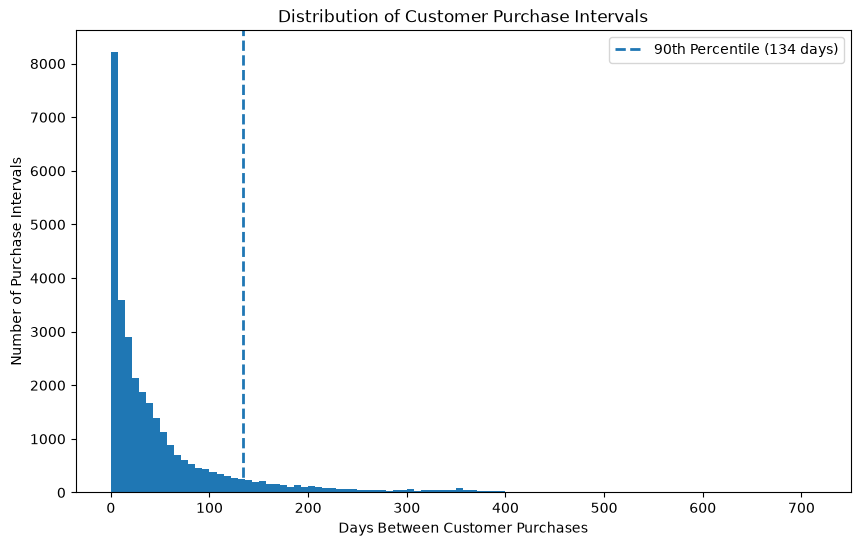

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    purchase_intervals,
    bins=100
)

plt.axvline(
    134.12,
    linestyle="--",
    linewidth=2,
    label="90th Percentile (134 days)"
)

plt.xlabel("Days Between Customer Purchases")
plt.ylabel("Number of Purchase Intervals")
plt.title("Distribution of Customer Purchase Intervals")
plt.legend()
plt.show()

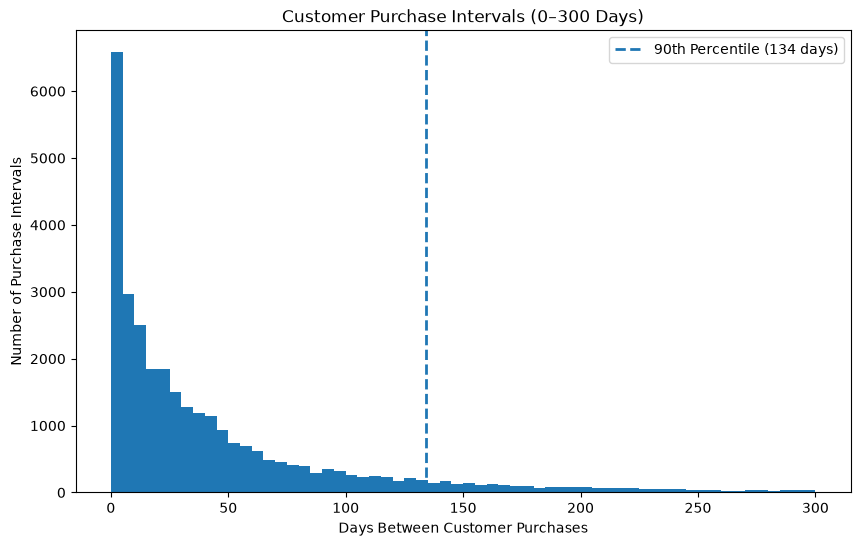

In [66]:
plt.figure(figsize=(10, 6))

plt.hist(
    purchase_intervals[purchase_intervals <= 300],
    bins=60
)

plt.axvline(
    134.12,
    linestyle="--",
    linewidth=2,
    label="90th Percentile (134 days)"
)

plt.xlabel("Days Between Customer Purchases")
plt.ylabel("Number of Purchase Intervals")
plt.title("Customer Purchase Intervals (0–300 Days)")
plt.legend()
plt.show()